# RAG with Azure AI Search

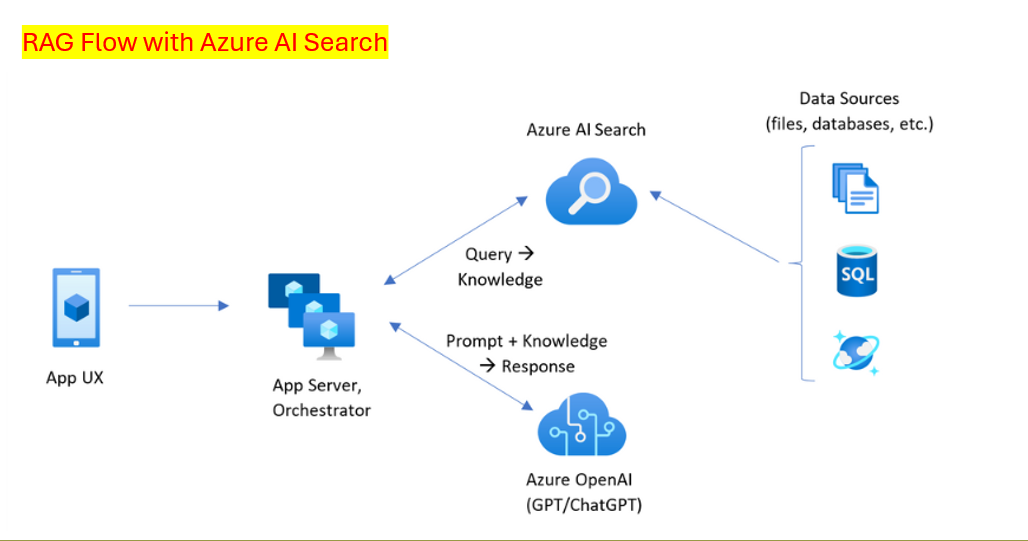

### Installing Packages

In [1]:
%pip install openai



Note: you may need to restart the kernel to use updated packages.


In [2]:
from openai import AzureOpenAI
import os
from dotenv import load_dotenv
load_dotenv()

service_endpoint = os.getenv('AZURE_SEARCH_SERVICE_ENDPOINT')
index_name = os.getenv('AZURE_SEARCH_INDEX_NAME')
key = os.getenv('AZURE_SEARCH_API_KEY')

#print(service_endpoint)
#print(index_name)
#print(key)

### Creating an Azure OpenAI Client

In [3]:
from openai import AzureOpenAI

azure_openai_endpoint = os.getenv('AZURE_OPENAI_ENDPOINT')
azure_openai_key = os.getenv('AZURE_OPENAI_KEY')

azure_openai_client = AzureOpenAI(
    api_key=azure_openai_key,
    api_version=os.getenv('OPENAI_API_VERSION'),
    azure_endpoint=azure_openai_endpoint
)

### Creating Embedding Generator Function

In [4]:
def generate_embeddings(client, text):
    embedding_model = os.getenv('EMBEDDING_ENGINE')

    response = client.embeddings.create(
        input=text,
        model = embedding_model
    )

    embeddings=response.model_dump()
    return embeddings['data'][0]['embedding']


In [5]:

user_query = "What is the review of the creek hotel in Dubai?"
vectorised_user_query = generate_embeddings(azure_openai_client, user_query)
print(vectorised_user_query)


[-0.012705029919743538, 0.03464516997337341, -0.010531268082559109, 0.02129206247627735, 0.03370005637407303, -0.020738497376441956, -0.00044470978900790215, 0.010436756536364555, -0.014122700318694115, 0.03126976639032364, 0.01288055069744587, -0.04112594947218895, 0.00545128108933568, -0.016242455691099167, -0.00797946099191904, -0.012853546999394894, -0.010909313336014748, -0.028191393241286278, 0.02183212898671627, 0.023533333092927933, -0.004901090171188116, 0.002970357658341527, 0.007857945747673512, -0.03656240180134773, 0.008769305422902107, 0.015027308836579323, -0.024788985028862953, -0.0036960700526833534, 0.065671905875206, -0.012421495281159878, 0.0240463949739933, 0.025018511340022087, -0.006095984019339085, -8.702219201950356e-05, -0.0315127931535244, 0.007736431434750557, 0.002950105117633939, 0.013319353573024273, 0.01590491458773613, 0.031458787620067596, -0.03102673590183258, -0.026881735771894455, 0.015486364252865314, 0.036913443356752396, -0.03650839626789093, -0.

In [6]:
context=[]

### Sending API call to the Search Index

In [7]:
import requests
import json


url = f"{service_endpoint}/indexes/{index_name}/docs/search?api-version=2023-11-01"

headers = {
        "Content-Type": "application/json",
        "api-key": key
    }

body =   {
        "count": True,
        "select": "chunk",
        "vectorQueries": [
            {
                "vector": vectorised_user_query,
                "k":  3,
                "fields": "text_vector",
                "kind": "vector"
            }
        ]
    }

response = requests.post(url, headers=headers, data=json.dumps(body))
documents = response.json()['value']

for doc in documents:
    context.append(dict(
        {
            "chunk": doc['chunk'],
            "score": doc['@search.score']

        }
    ))

for doc in context:
    print(doc)



{'chunk': "Average place - great location\r\nThe Creek Hotel, Dubai, UAE\r\n1/3/2018\r\nI stayed here twice last year; room was booked by a company I was doing business with in DXB.First\r\nof all, the hotel is in a great location in the middle of Bur Dubai. Lots of shopping nearby, many\r\nrestaurants, relatively close to the Creek, easy to get taxis. Within walking distance to a lot. Not sure\r\nof how easy it is to get to now (due to construction, etc). But not bad in last year.The hotel is one of\r\nthe older places in Dubai, and looks it. Kind of like a 1970s Holiday Inn that has not been updated.\r\nReception was efficient, if a bit indifferent. The porter was good. I had a one BR once and a one BR\r\nsuite once. Both were clean, if a bit worn. About what you'd expect from an older 3*. No problems\r\nwith housekeeping; clean sheets and linens. The one BR had a bed, OK mattress, dresser, desk and\r\nnightstand. The suite had a BR (just about the same as the one BR) and a good size

### Calling GPT Engine for Summarisation

In [8]:
system_prompt = f""""You are meant to behave as a RAG chatbot that derives its context from a database of hotel reviews stored in Azure AI Search Solution.
please answer strictly from the context from the database provided and if you dont have an answer please politely say so. dont include any extra
information that is not in the context and dont include links as well.
the context passed to you will be in the form of a pythonic list with each object in the list containing details of hotel reviews and
having structure as follows:

 "chunk": "the content of the review",
 "score": "the relevancy score of the review"


the pythonic list contains best 3 matches to the user query based on cosine similarity of the embeddings of the user query and the review descriptions.
please structure your answers in a very professional manner and in such a way that the user does not get to know that its RAG working under the hood
and its as if they are talking to a human. """

user_prompt = f""" the user query is: {user_query}
the context is : {context}"""

chat_completions_response = azure_openai_client.chat.completions.create(
    model = os.getenv('GPT_ENGINE'),
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ],
    temperature=0.7
)

print(chat_completions_response.choices[0].message.content)



The Creek Hotel in Dubai is described as an average place with a great location in the middle of Bur Dubai. The hotel is conveniently situated near shopping areas, restaurants, and is relatively close to the Creek, making it easy to access taxis and within walking distance to many attractions. Although it is one of the older hotels in Dubai and has not been updated, the reception is efficient, housekeeping is reliable, and rooms are clean, if somewhat worn. The furnishings are standard for a 2-3 star hotel and the prices are considered reasonable.

The hotel attracts a mix of customers, primarily businessmen and some tourists, with business activities frequently taking place in the lobby. The restaurant offers decent food, and the pub is noted as one of the first in Dubai. Facilities such as sofas, TV, and hot-shower baths are available. Overall, The Creek Hotel is suitable for those visiting Dubai for business or on a budget, offering fair service and comfortable rooms in a prime loca

CHATBOT EXPERIENCE

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import requests
import json

# Chat history list
chat_history = []

# Output widget to display chat messages
output_area = widgets.Output()

# Text input for user messages
text_input = widgets.Text(
    value='',
    placeholder='Type your message here...',
    description='You:',
    disabled=False
)

# Send button
send_button = widgets.Button(
    description='Send',
    disabled=False,
    button_style='',
    tooltip='Send your message',
    icon='paper-plane'
)

# Function to handle chat submissions
def on_send_button_clicked(b):
    user_message = text_input.value
    if not user_message:
        return

    # Clear input field
    text_input.value = ''

    # Add user message to history
    chat_history.append({"role": "user", "content": user_message})

    with output_area:
        output_area.clear_output()
        for msg in chat_history:
            if msg["role"] == "user":
                display(HTML(f"<b>You:</b> {msg['content']}"))
            else:
                display(HTML(f"<b>Chatbot:</b> {msg['content']}"))
        display(HTML("<i>Chatbot is thinking...</i>"))

    # --- RAG pipeline for chatbot response ---
    try:
        # 1. Generate embeddings for user query
        vectorised_user_query = generate_embeddings(azure_openai_client, user_message)

        # 2. Call Azure AI Search
        search_url = f"{service_endpoint}/indexes/{index_name}/docs/search?api-version=2023-11-01"
        search_headers = {
            "Content-Type": "application/json",
            "api-key": key
        }
        search_body = {
            "count": True,
            "select": "chunk",
            "vectorQueries": [
                {
                    "vector": vectorised_user_query,
                    "k":  3,
                    "fields": "text_vector",
                    "kind": "vector"
                }
            ]
        }
        search_response = requests.post(search_url, headers=search_headers, data=json.dumps(search_body))
        documents = search_response.json()['value']

        current_context = []
        for doc in documents:
            current_context.append(dict(
                {
                    "chunk": doc['chunk'],
                    "score": doc['@search.score']
                }
            ))

        # 3. Call GPT Engine for summarization/response
        system_prompt = """You are meant to behave as a RAG chatbot that derives its context from a database of hotel reviews stored in Azure AI Search Solution.
please answer strictly from the context from the database provided and if you dont have an answer please politely say so. dont include any extra
information that is not in the context and dont include links as well.
the context passed to you will be in the form of a pythonic list with each object in the list containing details of hotel reviews and
having structure as follows:

 "chunk": "the content of the review",
 "score": "the relevancy score of the review"


the pythonic list contains best 3 matches to the user query based on cosine similarity of the embeddings of the user query and the review descriptions.
please structure your answers in a very professional manner and in such a way that the user does not get to know that its RAG working under the hood
and its as if they are talking to a human. """

        gpt_user_prompt = f""" the user query is: {user_message}
the context is : {current_context}"""

        chat_completions_response = azure_openai_client.chat.completions.create(
            model = os.getenv('GPT_ENGINE'),
            messages = [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": gpt_user_prompt}
            ],
            temperature=0.7
        )
        ai_response = chat_completions_response.choices[0].message.content

    except Exception as e:
        ai_response = f"An error occurred: {e}"
        print(f"Error during RAG pipeline: {e}")

    # Add AI response to history
    chat_history.append({"role": "assistant", "content": ai_response})

    # Update output area with full chat history
    with output_area:
        output_area.clear_output()
        for msg in chat_history:
            if msg["role"] == "user":
                display(HTML(f"<b>You:</b> {msg['content']}"))
            else:
                display(HTML(f"<b>Chatbot:</b> {msg['content']}"))

# Link button click and text input submission to the function
send_button.on_click(on_send_button_clicked)
text_input.on_submit(on_send_button_clicked) # Trigger on Enter key

# Display the UI
display(output_area, text_input, send_button)

C:\Users\sr43993\AppData\Local\Temp\ipykernel_32412\1854352612.py:131: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  text_input.on_submit(on_send_button_clicked) # Trigger on Enter key


Output()

Text(value='', description='You:', placeholder='Type your message here...')

Button(description='Send', icon='paper-plane', style=ButtonStyle(), tooltip='Send your message')